# Model Project

Import and set magics:

## Question 1

**1.1.1**

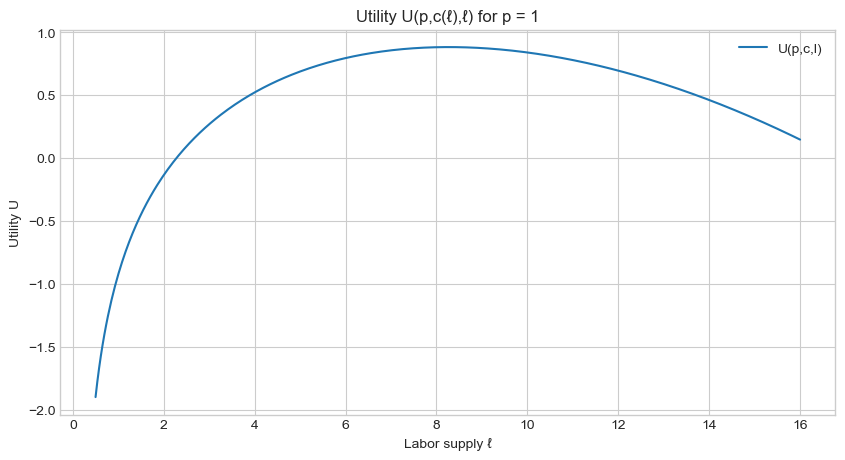

In [72]:
import numpy as np
from worker import WorkerClass
import matplotlib.pyplot as plt

# Making a subclass for workers
class MyWorkerClass(WorkerClass):
    def utility(self, c, ell):
        par = self.par
        return np.log(c) - par.nu * (ell ** (1 + par.epsilon)) / (1 + par.epsilon)

    # Define the tax 
    def tax(self, pre_tax_income):
        par = self.par
        tax = par.tau * pre_tax_income + par.zeta
        if not np.isnan(par.kappa):
            tax += par.omega * np.fmax(pre_tax_income - par.kappa, 0)
        return tax
    # Define disposable income
    def income(self, p, ell):
        par = self.par
        return par.w * p * ell
    # Define the FOC
    def FOC(self, p, ell):
        par = self.par
        pre_tax_income = self.income(p, ell)
        
        marginal_tax = par.tau
        if not np.isnan(par.kappa):
            marginal_tax += par.omega * (pre_tax_income > par.kappa)
            
        marginal_income = par.w * p * (1 - marginal_tax)
        
        # Marginal disutility of labor
        marginal_disutility = par.nu * ell**par.epsilon

        c = self.post_tax_income(p, ell)
        return (1/c) * marginal_income - marginal_disutility

# Define pi = 1
p = 1.0

worker = MyWorkerClass()

# Interval for ell 
ell_grid = np.linspace(0.5, worker.par.ell_max, 400)

c_grid = worker.post_tax_income(p, ell_grid)
U_grid = worker.utility(c_grid, ell_grid)

# Plot the figure 
plt.figure(figsize=(10,5))
plt.plot(ell_grid, U_grid, label="U(p,c,l)")
plt.xlabel("Labor supply ℓ")
plt.ylabel("Utility U")
plt.title("Utility U(p,c(ℓ),ℓ) for p = 1")
plt.grid(True)
plt.legend()
plt.show()

**1.1.2**

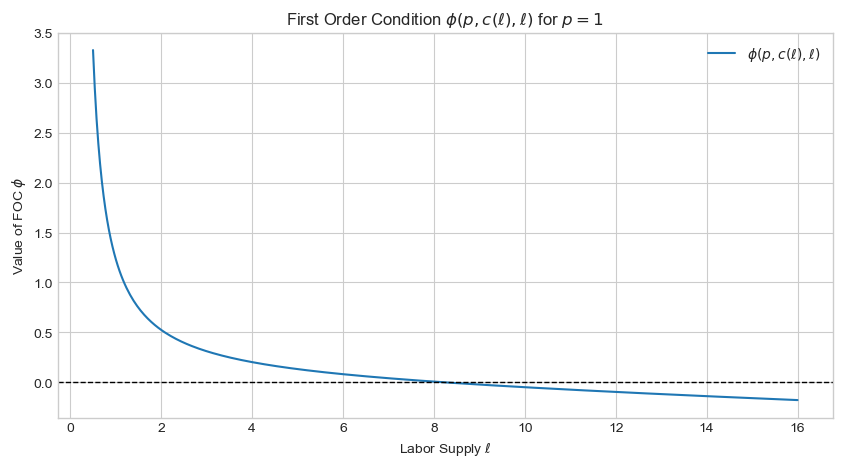

In [73]:
# Calculate FOC values using the worker instance from 1.1.1
phi_grid = worker.FOC(p, ell_grid)

# Plot
plt.figure(figsize=(10,5))
plt.plot(ell_grid, phi_grid, label=r'$\phi(p,c(\ell),\ell)$')
plt.axhline(0, color='black', linestyle='--', linewidth=1) 

plt.xlabel(r'Labor Supply $\ell$')
plt.ylabel(r'Value of FOC $\phi$')
plt.title(r'First Order Condition $\phi(p,c(\ell),\ell)$ for $p = 1$')
plt.grid(True)
plt.legend()
plt.show()

**1.1.3**

In [74]:
from scipy.optimize import minimize_scalar 

par = worker.par

# Lower minimum (c >= 0)
ell_min = par.zeta / ((1 - par.tau) * par.w * p) 
ell_max = par.ell_max

# Objective function: minus U (minimize)
def obj(ell):
    c = worker.post_tax_income(p, ell)
    return -worker.utility(c, ell)

# Numerical optimum
res = minimize_scalar(obj, bounds=(ell_min, ell_max), method='bounded')

ell_star = res.x

print(f"Optimal ell*(p={p}) = {ell_star}")

Optimal ell*(p=1.0) = 8.26557814073325


**1.1.4**

In [75]:
from scipy.optimize import root_scalar
#Set the function equal to zero
def phi(ell):
    return worker.FOC(p, ell)

# Add a small buffer to avoid division by zero 
ell_min_safe = ell_min + 1e-6

# Check for sign change before running root_scalar
phi_min = phi(ell_min_safe)
phi_max = phi(ell_max)

if phi_min * phi_max > 0:
    ell_star_foc = ell_max if phi_min > 0 else ell_min_safe
else:
    res = root_scalar(phi, bracket=(ell_min_safe, ell_max), method='brentq')
    ell_star_foc = res.root

print(f"Optimal ell*_FOC(p={p}) = {ell_star_foc}")

Optimal ell*_FOC(p=1.0) = 8.265578158750735


**1.1.5**

The answers for both are pretty similar, as you can only see a difference from the 8th decimal point. The minimize scalar finds the value where the function is at its lowest, whereas the root scalar finds the value where the function is equal to zero. Both the functions were pretty quick, but we found that the root scalar was a little quicker. 

**1.1.6**

epsilon = 1.0
  optimizer ell* = 8.265578140757935
  root-finder ell* = 8.26557815874913

epsilon = 0.75
  optimizer ell* = 11.13604844948733
  root-finder ell* = 11.136048181678659

epsilon = 0.5
  optimizer ell* = 15.99999606847445
  root-finder ell* = 16.0



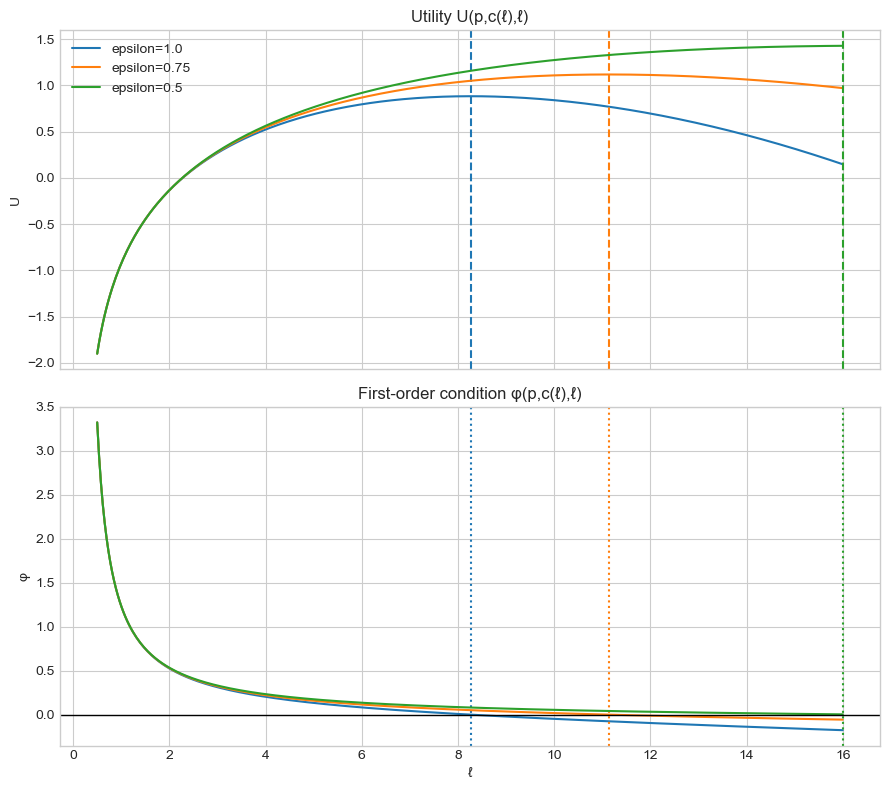

In [76]:


def solve_for_epsilon(eps, axU, axPhi):
    # Use MyWorkerClass 
    worker = MyWorkerClass(par={"epsilon": eps})
    par = worker.par
    p = 1.0

    ell = np.linspace(0.5, par.ell_max, 400)

    c = worker.post_tax_income(p, ell)
    U = worker.utility(c, ell)
    axU.plot(ell, U, label=f"epsilon={eps}")

    phi = [worker.FOC(p, e) for e in ell]
    axPhi.plot(ell, phi, label=f"epsilon={eps}")

    # Minimize -utility
    def obj(x):
        return -(worker.utility(worker.post_tax_income(p, x), x))

    # Use get_min_ell from worker class
    ell_min = worker.get_min_ell(p)
    ell_max = par.ell_max

    res_opt = minimize_scalar(obj, bounds=(ell_min, ell_max), method="bounded")
    ell_star_opt = res_opt.x

    # root finder
    def phi_single(x):
        return worker.FOC(p, x)

    # Check for sign change
    if phi_single(ell_min) * phi_single(ell_max) > 0:
        ell_star_root = ell_max if phi_single(ell_min) > 0 else ell_min
    else:
        res_root = root_scalar(phi_single, bracket=(ell_min, ell_max), method="bisect")
        ell_star_root = res_root.root

    # Print the results
    print(f"epsilon = {eps}")
    print(f"  optimizer ell* = {ell_star_opt}")
    print(f"  root-finder ell* = {ell_star_root}\n")

    # Plot vertical lines
    axU.axvline(ell_star_opt, linestyle="--", color=axU.lines[-1].get_color())
    axPhi.axvline(ell_star_root, linestyle=":", color=axPhi.lines[-1].get_color())


fig, (axU, axPhi) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for eps in [1.0, 0.75, 0.50]:
    solve_for_epsilon(eps, axU, axPhi)

# Finalize plots
axU.set_title("Utility U(p,c(ℓ),ℓ)")
axU.set_ylabel("U")
axU.legend()

axPhi.set_title("First-order condition φ(p,c(ℓ),ℓ)")
axPhi.axhline(0, color="black", linewidth=1)
axPhi.set_ylabel("φ")
axPhi.set_xlabel("ℓ")

# Plot
plt.tight_layout()
plt.show()

**1.2.1**


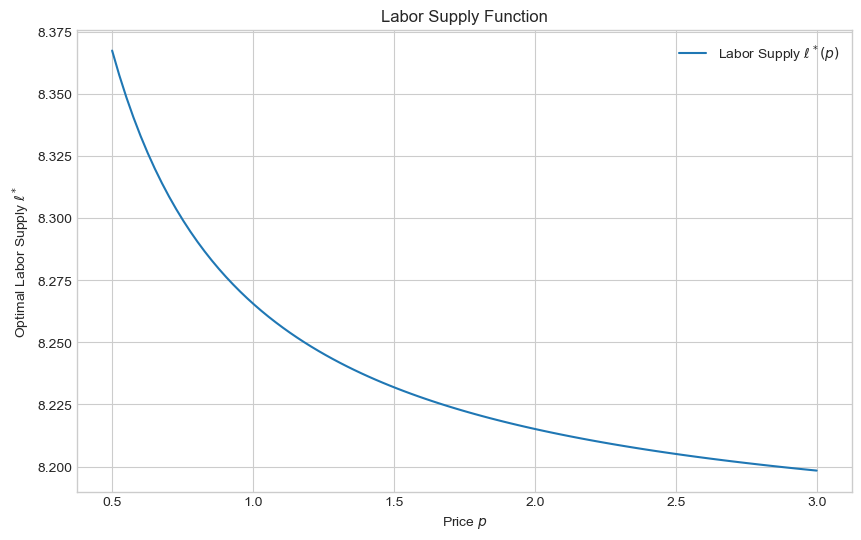

In [77]:
# Initialize the worker class (previously defined)
worker = MyWorkerClass()
par = worker.par

# Define vector of prices
p_vec = np.linspace(0.5, 3.0, 100)
ell_vec = np.zeros(p_vec.shape)

# Find optimal labor supply for each price
for i, p in enumerate(p_vec):
    
    # Define objective function (negative utility)
    def obj(ell):
        c = worker.post_tax_income(p, ell)
        return -worker.utility(c, ell)
    
    # Find bounds
    ell_min = worker.get_min_ell(p)
    ell_max = par.ell_max
    
    # Optimize
    res = minimize_scalar(obj, bounds=(ell_min, ell_max), method='bounded')
    ell_vec[i] = res.x

# Plot results
plt.figure(figsize=(10,6))
plt.plot(p_vec, ell_vec, label=r'Labor Supply $\ell^*(p)$')
plt.xlabel('Price $p$')
plt.ylabel('Optimal Labor Supply $\ell^*$')
plt.title('Labor Supply Function')
plt.grid(True)
plt.legend()
plt.show()

**1.2.2**

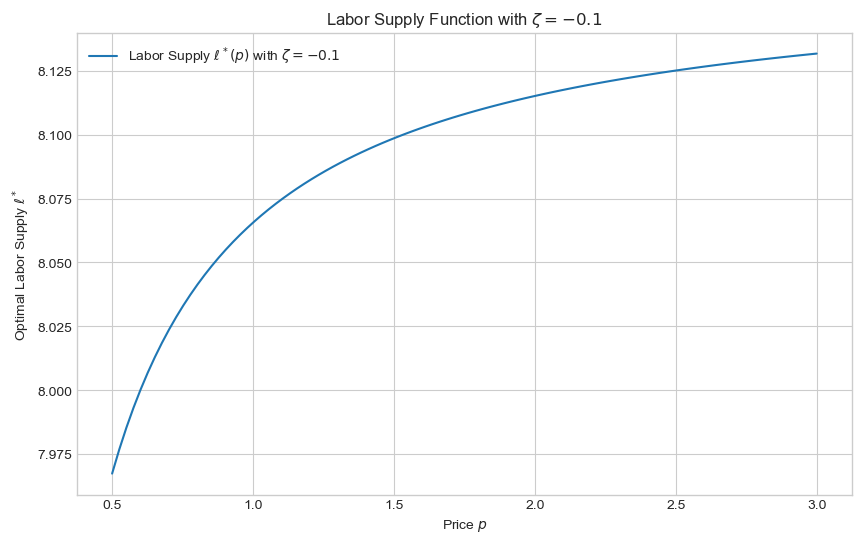

In [78]:
# Workerclass with zeta = -0.1
worker_zeta = MyWorkerClass(par={'zeta': -0.1})
par_zeta = worker_zeta.par

# Define vector prices
ell_vec_zeta = np.zeros(p_vec.shape)

# Find optimal labor supply
for i, p in enumerate(p_vec):
    
    # Define objective function (negative utility)
    def obj(ell):
        c = worker_zeta.post_tax_income(p, ell)
        return -worker_zeta.utility(c, ell)

    ell_min = worker_zeta.get_min_ell(p)
    ell_max = par_zeta.ell_max
    
    # Optimize
    res = minimize_scalar(obj, bounds=(ell_min, ell_max), method='bounded')
    ell_vec_zeta[i] = res.x

# Plot results
plt.figure(figsize=(10,6))
plt.plot(p_vec, ell_vec_zeta, label=r'Labor Supply $\ell^*(p)$ with $\zeta = -0.1$')
plt.xlabel('Price $p$')
plt.ylabel('Optimal Labor Supply $\ell^*$')
plt.title(r'Labor Supply Function with $\zeta = -0.1$')
plt.grid(True)
plt.legend()
plt.show()

**2.1**

In [79]:
from types import SimpleNamespace

import numpy as np

from scipy.optimize import minimize_scalar
from scipy.optimize import root_scalar

class WorkerClass:

    def __init__(self,par=None):

        # a. setup
        self.setup_worker()

        # b. update parameters
        if not par is None: 
            for k,v in par.items():
                self.par.__dict__[k] = v

    def setup_worker(self):

        par = self.par = SimpleNamespace()
        sol = self.sol = SimpleNamespace()

        # a. preferences
        par.nu = 0.015 # weight on labor disutility
        par.epsilon = 1.0 # curvature of labor disutility
        
        # b. productivity and wages
        par.w = 1.0 # wage rate
        par.ps = np.linspace(0.5,3.0,100) # productivities
        par.ell_max = 16.0 # max labor supply
        
        # c. taxes
        par.tau = 0.50 # proportional tax rate
        par.zeta = 0.10 # lump-sum tax
        par.kappa = np.nan # income threshold for top tax
        par.omega = 0.20 # top rate rate
          
    def utility(self,c,ell):

        par = self.par

        return np.log(c) - par.nu*(ell**(1+par.epsilon))/(1+par.epsilon)
    
    def tax(self,pre_tax_income):

        par = self.par

        tax = par.tau * pre_tax_income
        if pre_tax_income > par.kappa:
            tax += par.omega * (pre_tax_income - par.kappa)
        
        return tax
    
    def income(self,p,ell):

        par = self.par

        return par.w*p*ell

    def post_tax_income(self,p,ell):

        pre_tax_income = self.income(p,ell)
        tax = self.tax(pre_tax_income)

        return pre_tax_income - tax + par.zeta
    
    def max_post_tax_income(self,p):

        par = self.par
        return self.post_tax_income(p,par.ell_max)

    def value_of_choice(self,p,ell):

        par = self.par

        c = self.post_tax_income(p,ell)
        if c <= 0:
            return -np.inf
        
        U = self.utility(c,ell)

        return U
    
    def get_min_ell(self,p):
    
        par = self.par

        min_ell = par.zeta/(par.w*p*(1-par.tau))

        return np.fmax(min_ell,0.0) + 1e-8
    
    def optimal_choice(self,p):

        par = self.par
        opt = SimpleNamespace()

        # a. objective function
        def obj(ell):
            return -self.value_of_choice(p,ell)

        # b. bounds and minimization
        res = minimize_scalar(obj, bounds=(0, par.ell_max), method='bounded')

        # c. results
        opt.ell = res.x
        opt.U = -res.fun
        opt.c = self.post_tax_income(p,opt.ell)

        return opt
    
    def FOC(self,p,ell):

        par = self.par

        # a. derivative of utility wrt. c
        deriv_u = 1/self.post_tax_income(p,ell)
        
        # b. derivative of post_tax_income wrt. ell
        deriv_c = par.w*p*(1-par.tau)
        if self.income(p,ell) > par.kappa:
            deriv_c -= par.w*p*par.omega

        # c. FOC
        FOC = deriv_u*deriv_c - par.nu*ell**par.epsilon
        return FOC
    
    def optimal_choice_FOC(self,p):

        par = self.par
        opt = SimpleNamespace()

        # a. objective
        def obj(ell):
            return self.FOC(p,ell)

        # b. root finding
        try:
            res = root_scalar(obj, bracket=[1e-8, par.ell_max], method='brentq')
            opt.ell = res.root
        except ValueError:
            opt.ell = 0

        # c. results
        opt.c = self.post_tax_income(p,opt.ell)
        opt.U = self.value_of_choice(p,opt.ell)
        
        return opt

In [80]:
class GovernmentClass(WorkerClass):

    def __init__(self,par=None):

        # a. defaul setup
        self.worker = WorkerClass()
        self.par = self.worker.par
        self.sol = self.worker.sol
        self.setup_government()

        # b. update parameters
        if not par is None: 
            for k,v in par.items():
                self.par.__dict__[k] = v
                self.worker.par.__dict__[k] = v

        # c. random number generator
        self.rng = np.random.default_rng(12345)

    def setup_government(self):

        par = self.par

        # a. workers
        par.N = 100  # number of workers
        par.sigma_p = 0.3  # std dev of productivity

        # b. pulic good
        par.chi = 0.5*par.N # weight on public good in SWF
        par.eta = 0.1 # curvature of public good in SWF

    def draw_productivities(self):

        par = self.par
        
        log_p = self.rng.normal(loc=-0.5*par.sigma_p**2, scale=par.sigma_p, size=par.N)
        self.sol.ps = np.exp(log_p)

    def solve_workers(self):

        par = self.par
        sol = self.sol

        sol.ells = np.zeros(par.N)
        sol.cs = np.zeros(par.N)
        sol.Us = np.zeros(par.N)

        for i,p in enumerate(sol.ps):
            opt = self.worker.optimal_choice(p)
            sol.ells[i] = opt.ell
            sol.cs[i] = opt.c
            sol.Us[i] = opt.U
            
    def tax_revenue(self):

        par = self.par
        sol = self.sol

        tax_revenue = 0
        for i,p in enumerate(sol.ps):
            pre_tax_income = self.worker.income(p,sol.ells[i])
            tax_revenue += self.worker.tax(pre_tax_income)
        
        tax_revenue -= par.N*par.zeta

        return tax_revenue
    
    def SWF(self):

        par = self.par
        sol = self.sol

        G =  self.tax_revenue()
        if G < 0:
            SWF = -np.inf
        else:
            SWF = par.chi*(G**par.eta) + np.sum(sol.Us)

        return SWF
    
    def optimal_taxes(self,method='Nelder-Mead',do_print=True):

        par = self.par

        # a. objective function
        def obj(x):

            par.tau = x[0]
            par.zeta = x[1]
            self.worker.par.tau = x[0]
            self.worker.par.zeta = x[1]

            self.solve_workers()
            
            return -self.SWF()
        
        # b. optimization
        x0 = [par.tau,par.zeta]
        res = minimize(obj,x0,method=method)
        
        # c. results
        if do_print:
            print(res)
        
        return res.x[0],res.x[1]
        

2. Public good

T = 387.912, SWF = 178.742


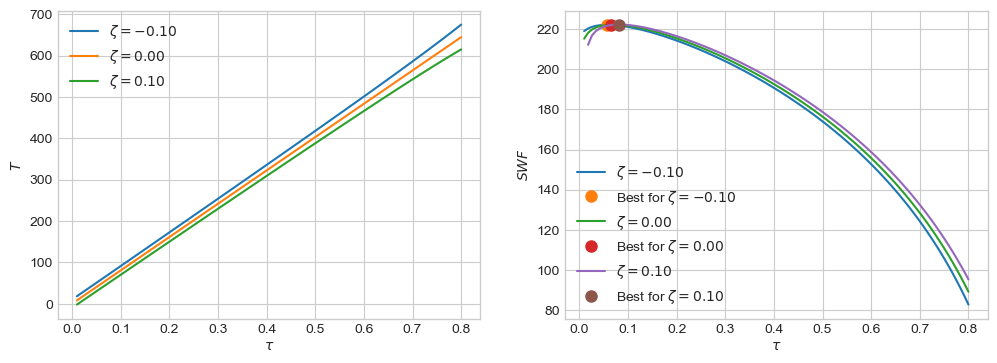

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -222.38407324785715
             x: [ 1.368e-01  5.235e-01]
           nit: 59
          nfev: 108
 final_simplex: (array([[ 1.368e-01,  5.235e-01],
                       [ 1.368e-01,  5.236e-01],
                       [ 1.368e-01,  5.236e-01]]), array([-2.224e+02, -2.224e+02, -2.224e+02]))
tau_opt = 0.137, zeta_opt = 0.524
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -222.3840732476375
             x: [ 1.368e-01  5.236e-01]
           nit: 55
          nfev: 108
 final_simplex: (array([[ 1.368e-01,  5.236e-01],
                       [ 1.368e-01,  5.235e-01],
                       [ 1.368e-01,  5.236e-01]]), array([-2.224e+02, -2.224e+02, -2.224e+02]))
tau_opt_new = 0.137, zeta_opt_new = 0.524


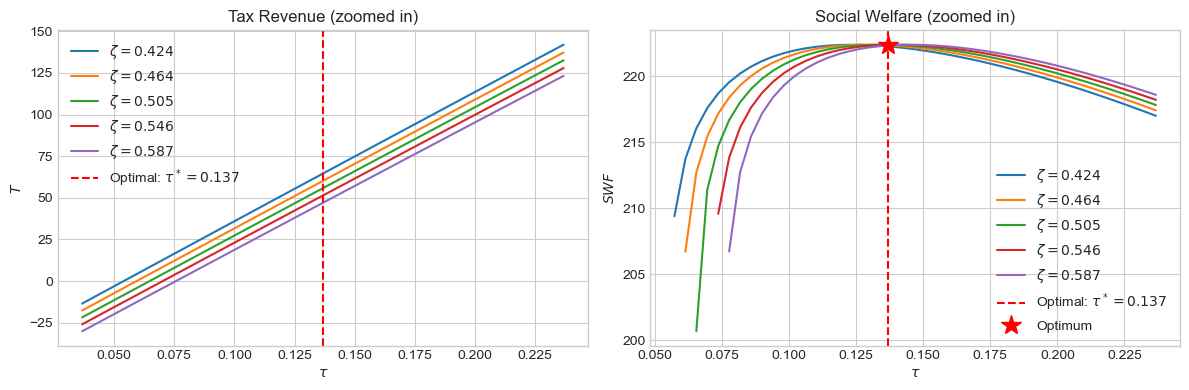

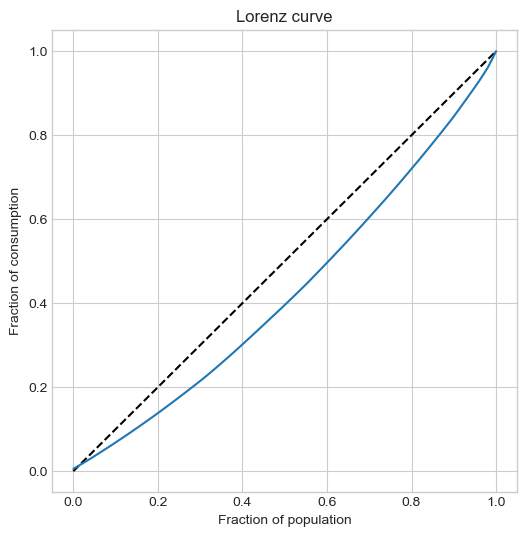

In [81]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Create a government instance to run our tax policy experiments
gov = GovernmentClass()
par = gov.par
sol = gov.sol

# Draw random productivity levels for our workers (this varies each run)
gov.draw_productivities()

# c. solve for tau = 0.5 and zeta = 0.1
par.tau = 0.5
par.zeta = 0.1
gov.solve_workers()
T = gov.tax_revenue()
SWF = gov.SWF()

print(f'T = {T:.3f}, SWF = {SWF:.3f}')

# Now let's visualize how tax revenue and welfare change with different tax rates
def plot_T_and_SWF(gov,zetas,taus):

    # Set up arrays to store results
    Ts = np.zeros((len(zetas),len(taus)))
    SWFs = np.zeros((len(zetas),len(taus)))

    # Run simulations across different tax combinations
    for i,zeta in enumerate(zetas):
        for j,tau in enumerate(taus):
            gov.par.zeta = zeta
            gov.par.tau = tau
            gov.solve_workers()
            Ts[i,j] = gov.tax_revenue()
            SWFs[i,j] = gov.SWF()

    # Create plots showing the trade-offs
    fig = plt.figure(figsize=(12,4))
    
    ax = fig.add_subplot(1,2,1)
    for i,zeta in enumerate(zetas):
        ax.plot(taus,Ts[i,:],label=f'$\\zeta = {zeta:.2f}$')
    ax.set_xlabel('$\\tau$')
    ax.set_ylabel('$T$')
    ax.legend()

    ax = fig.add_subplot(1,2,2)
    for i,zeta in enumerate(zetas):
        ax.plot(taus,SWFs[i,:],label=f'$\\zeta = {zeta:.2f}$')
        
        # Find the best tax rate for this transfer level
        max_idx = np.argmax(SWFs[i,:])
        max_tau = taus[max_idx]
        max_swf = SWFs[i,max_idx]
        ax.plot(max_tau, max_swf, 'o', markersize=8, label=f'Best for $\\zeta = {zeta:.2f}$')

    ax.set_xlabel('$\\tau$')
    ax.set_ylabel('$SWF$')
    ax.legend()

    plt.show()

# Test different transfer levels and see how welfare responds
zetas = [-0.1,0.0,0.1]
taus = np.linspace(0.01,0.8,100)
plot_T_and_SWF(gov,zetas,taus)

# Now optimize - find the exact best combination of tax rate and transfer
tau_opt,zeta_opt = gov.optimal_taxes()
print(f'tau_opt = {tau_opt:.3f}, zeta_opt = {zeta_opt:.3f}')

# Double-check our result by starting from a different point
gov.par.tau = tau_opt-0.05
gov.par.zeta = zeta_opt-0.05
tau_opt_new,zeta_opt_new = gov.optimal_taxes()
print(f'tau_opt_new = {tau_opt_new:.3f}, zeta_opt_new = {zeta_opt_new:.3f}')

# Zoom in on the optimal region to really see what's going on
def plot_close_to_optimum(gov, tau_opt, zeta_opt):
    
    # Focus on a narrow range around our optimum
    tau_range = np.linspace(tau_opt - 0.1, tau_opt + 0.1, 50)
    zeta_range = np.linspace(zeta_opt - 0.1, zeta_opt + 0.1, 50)
    
    # Store our detailed results
    Ts = np.zeros((len(zeta_range), len(tau_range)))
    SWFs = np.zeros((len(zeta_range), len(tau_range)))
    
    # Run simulations on the fine grid
    for i, zeta in enumerate(zeta_range):
        for j, tau in enumerate(tau_range):
            gov.par.zeta = zeta
            gov.par.tau = tau
            gov.solve_workers()
            Ts[i, j] = gov.tax_revenue()
            SWFs[i, j] = gov.SWF()
    
    # Show both tax revenue and welfare in the zoomed view
    fig = plt.figure(figsize=(12, 4))
    
    ax = fig.add_subplot(1, 2, 1)
    for i, zeta in enumerate(zeta_range[::10]):  # Skip every 10th line to avoid clutter
        idx = i * 10
        ax.plot(tau_range, Ts[idx, :], label=f'$\\zeta = {zeta:.3f}$')
    ax.axvline(x=tau_opt, color='red', linestyle='--', label=f'Optimal: $\\tau^* = {tau_opt:.3f}$')
    ax.set_xlabel('$\\tau$')
    ax.set_ylabel('$T$')
    ax.set_title('Tax Revenue (zoomed in)')
    ax.legend()
    
    ax = fig.add_subplot(1, 2, 2)
    for i, zeta in enumerate(zeta_range[::10]):  # Skip lines for readability
        idx = i * 10
        ax.plot(tau_range, SWFs[idx, :], label=f'$\\zeta = {zeta:.3f}$')
    ax.axvline(x=tau_opt, color='red', linestyle='--', label=f'Optimal: $\\tau^* = {tau_opt:.3f}$')
    
    # Mark the actual optimum with a big star
    gov.par.tau = tau_opt
    gov.par.zeta = zeta_opt
    gov.solve_workers()
    ax.plot(tau_opt, gov.SWF(), 'r*', markersize=15, label='Optimum')
    
    ax.set_xlabel('$\\tau$')
    ax.set_ylabel('$SWF$')
    ax.set_title('Social Welfare (zoomed in)')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Plot the optimal solution in detail
gov.par.tau = tau_opt
gov.par.zeta = zeta_opt
plot_close_to_optimum(gov, tau_opt, zeta_opt)

# Finally, look at the consumption distribution to check for inequality
def lorenz_curve(gov):

    # i. solve workers
    gov.solve_workers()

    # Sort consumption from poorest to richest
    cs_sorted = np.sort(gov.sol.cs)

    # Calculate cumulative consumption (how much the bottom x% have)
    cum_cs = np.cumsum(cs_sorted)
    
    # Normalize so it goes from 0 to 1
    total_c = cum_cs[-1]
    lorenz = cum_cs/total_c

    # Plot the Lorenz curve
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    ax.plot([0,1],[0,1],color='k',linestyle='--')  # Perfect equality line
    ax.plot(np.linspace(0,1,gov.par.N),lorenz)  # Actual distribution
    ax.set_xlabel('Fraction of population')
    ax.set_ylabel('Fraction of consumption')
    ax.set_title('Lorenz curve')
    plt.show()

# Show the distribution of consumption under our optimal system
gov.par.tau = tau_opt
gov.par.zeta = zeta_opt
lorenz_curve(gov)

### Question 2.1
We have first calculated the tax revenue (T) and the social welfare function (SWF) when 
The tax revenue is calculated to 387,912 and SWF to 178,742. 

**Tax revenue:**

In general, the two plots show that SWF and T changes when we vary `τ` and `ζ`. The plot on the left shows how the tax revenue changes for different values of `ζ`. The higher the `ζ` value the less tax provenue because lump sump transfers decrease labor supply. It shows that when the tax rate `τ` increases then tax revenue also increases. However, at higher tax rates there is a substitution away from labor because individuals begin to reduce their labor supply because of a lack of incentives. This is a central trade off in public economics, that the government collect taxes to finance public goods, but the extra taxes decrease the labor supply.

**SWF plot**

The plot shows that the connection between the tax rate and SWF is also a concave function. First welfare increases when the tax rate increases because the value of the public good exceeds the value loss for individuals imposed by the taxes. After a certain point marked by a circle the marginal welfare loss becomes greater than the marginal welfare gain from more public goods so the aggregate SWF decreases. The circles shows the welfare maximizing tax rates for different levels for `ζ`.


### Question 2.2

* **The Optimal Tax System:**

To find the optimal combination of `τ` and `ζ` we have used a numerical optimization algorithm that maximizes SWF. In order to maximize SWF the tax rate needs to be τ = 0,137 and the lump sum transfer is ζ = 0.524. To make sure that we have the right result, we try a new starting guess for the optimization. We get the same result, so it is likely that we have found the correct solution for a global maximum of SWF

We have made to figures above that shows the tax revenue and social welfare in a narrow range around the optimal values τ* and ζ*. These plots zoom in on the region where the optimization algorithm found its maximum, making it easier to see how the functions behave near the optimum.

**Inequality under the optimal tax system**
We have plotted the Lorenz curve under the optimal tax system, because it shows the distribution of consumption in the economy. The 45-degree represents perfect equality. The blue line below is the Lorenz curve and the further away the Lorenz curve is from the 45-degree line the more equality there is. 

We can see that under the optimal tax system there still is some inequality because the poorest 50% consumes less than half of total consumption. This is an expected result because the workers productivity is lognormal distributed and therefore different from each other. 

The tax system has a positive value of `ζ` (public transfer) so there is a redistribution of consumption which reduces inequality compared to a system without lump sum transfers. So the optimal tax system both generates a revenue to be spend on public goods, reduces inequality while avoiding an unnecessary big deadweight loss of taxation. 


# Question 3

In [82]:
%load_ext autoreload
%autoreload 2

from labour_supply_analysis import initialize_model, plot_simple_budget_constraint

# Initialize model
model, par = initialize_model()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parameters set: kappa = 9.0, omega = 0.2, tau = 0.137, zeta = 0.0
Worker parameters: w = 1.0, nu = 0.015, epsilon = 1.0, ell_max = 16.0
Distribution parameters: sigma_p = 0.3, chi = 50.0, eta = 0.1


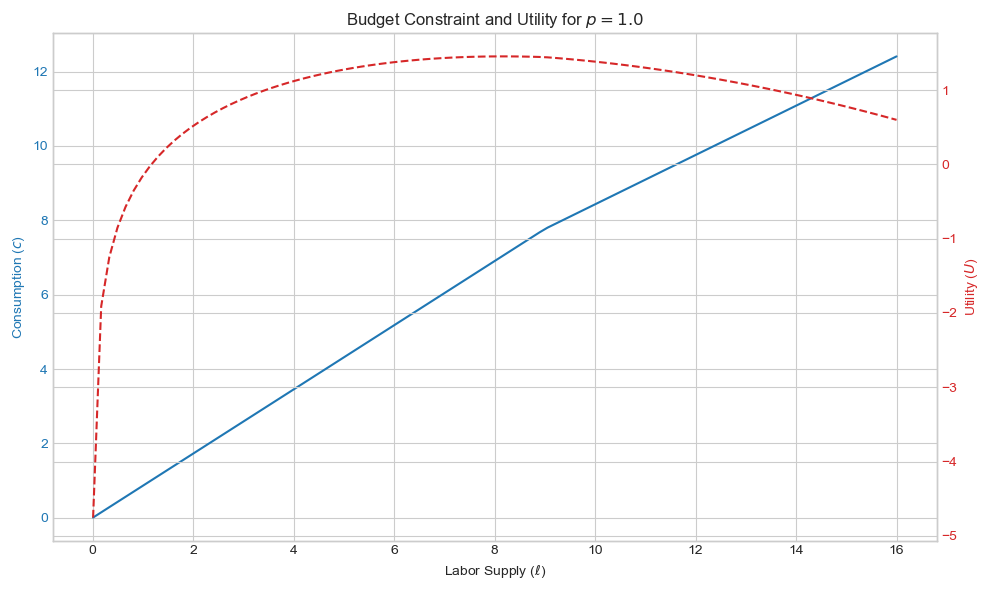

In [83]:
# Simple budget constraint visualization
plot_simple_budget_constraint(model, par, p_val=1.0)

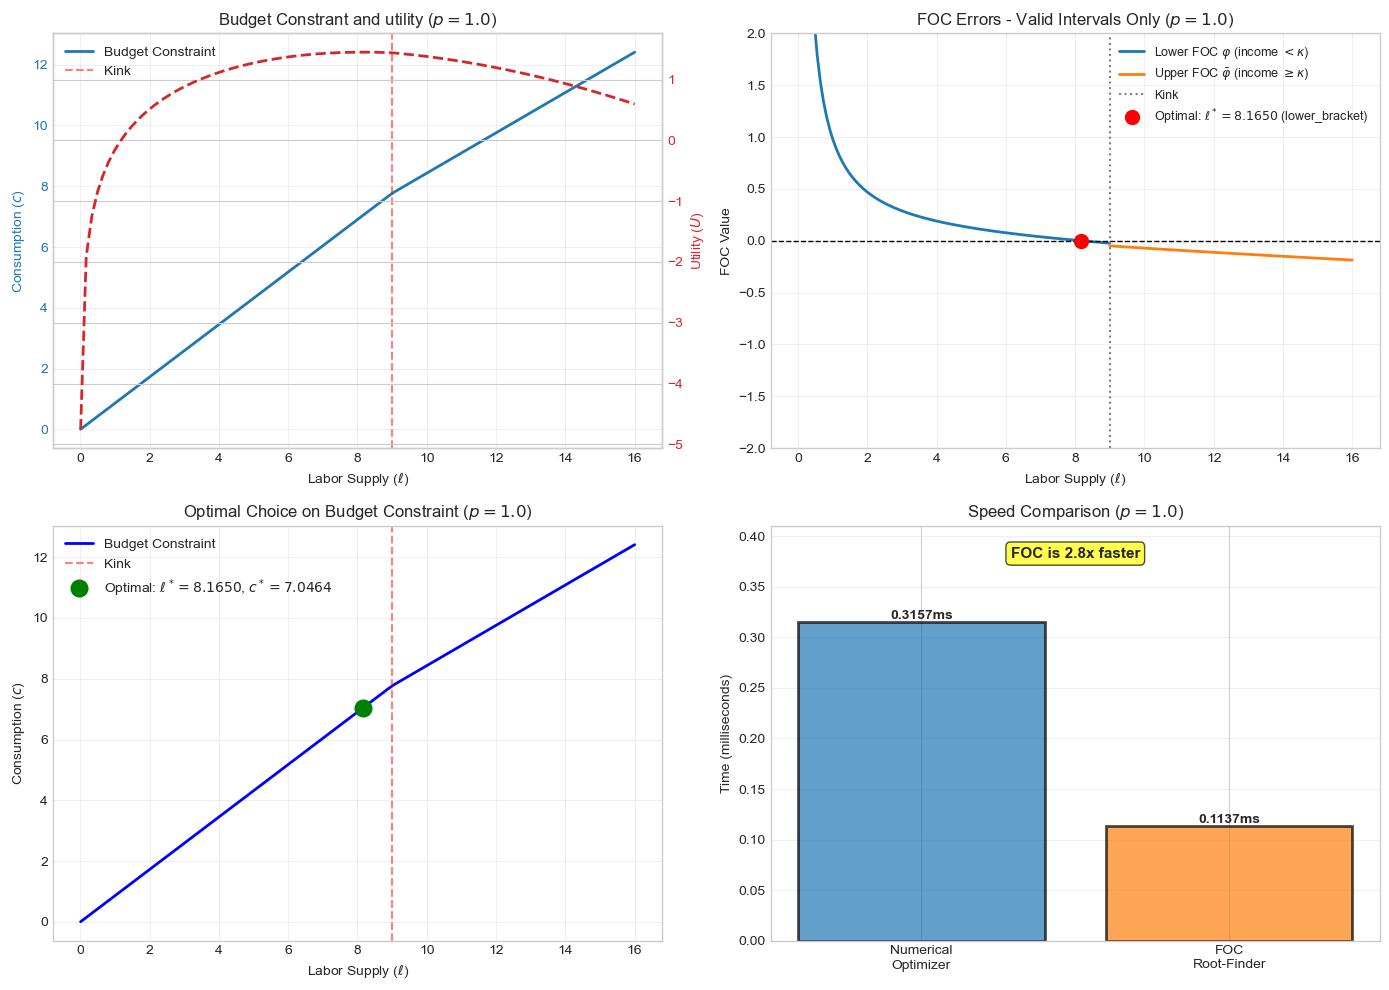


 Summary for p=1.0 ===
Optimal labor supply: 8.1650
Solution: lower_bracket
Consumption: 7.0464
Utility: 1.4525
Speed comparison: Numerical 0.3157ms, FOC 0.1137ms, Speedup 2.8x


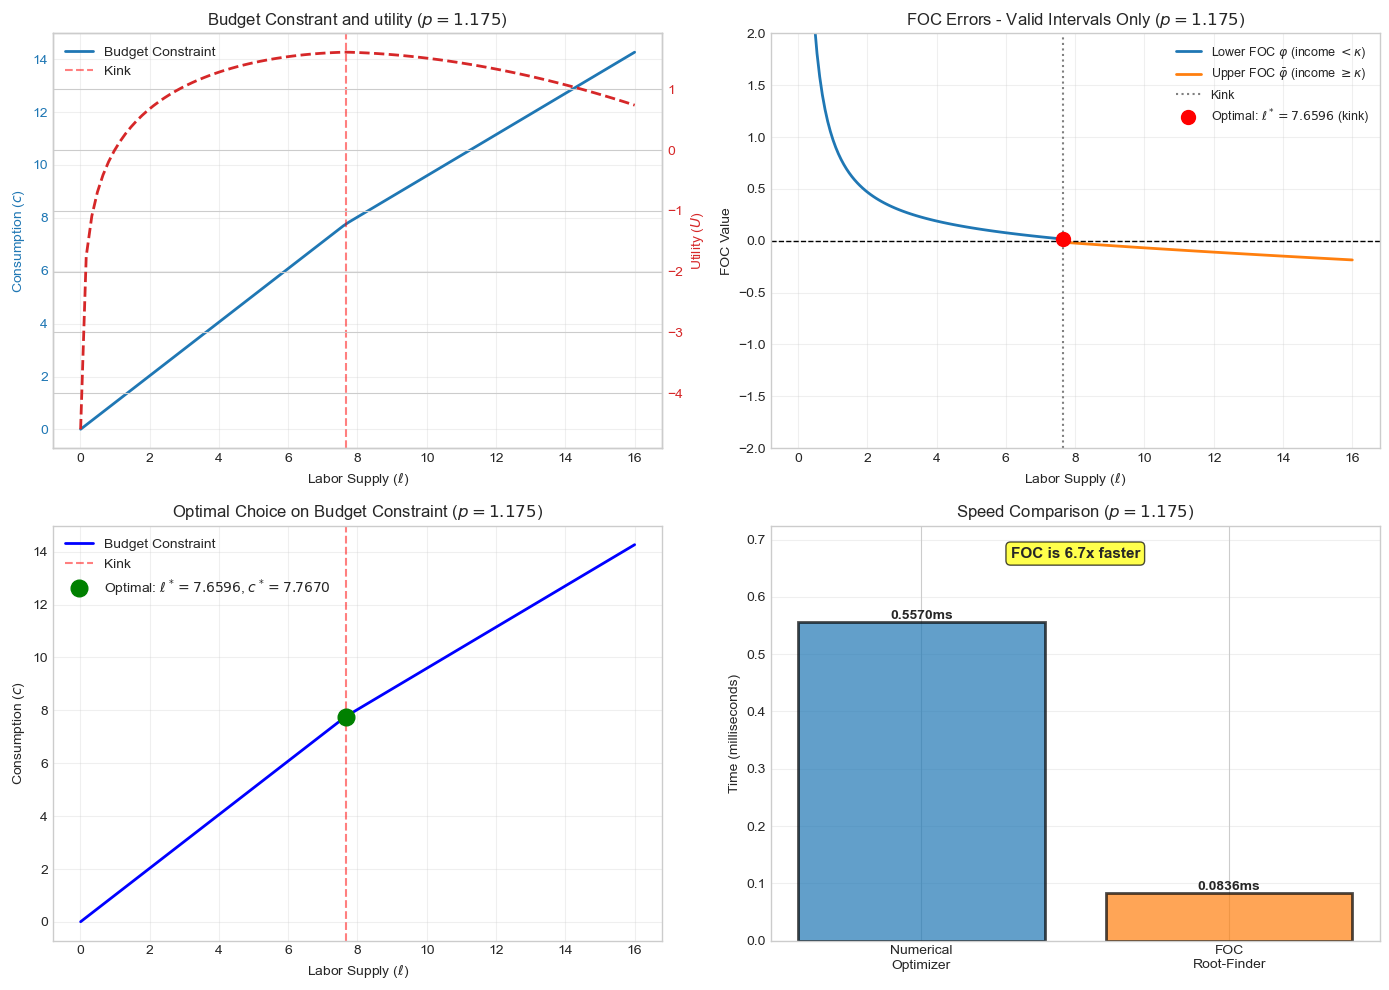


 Summary for p=1.175 ===
Optimal labor supply: 7.6596
Solution: kink
Consumption: 7.7670
Utility: 1.6099
Speed comparison: Numerical 0.5570ms, FOC 0.0836ms, Speedup 6.7x


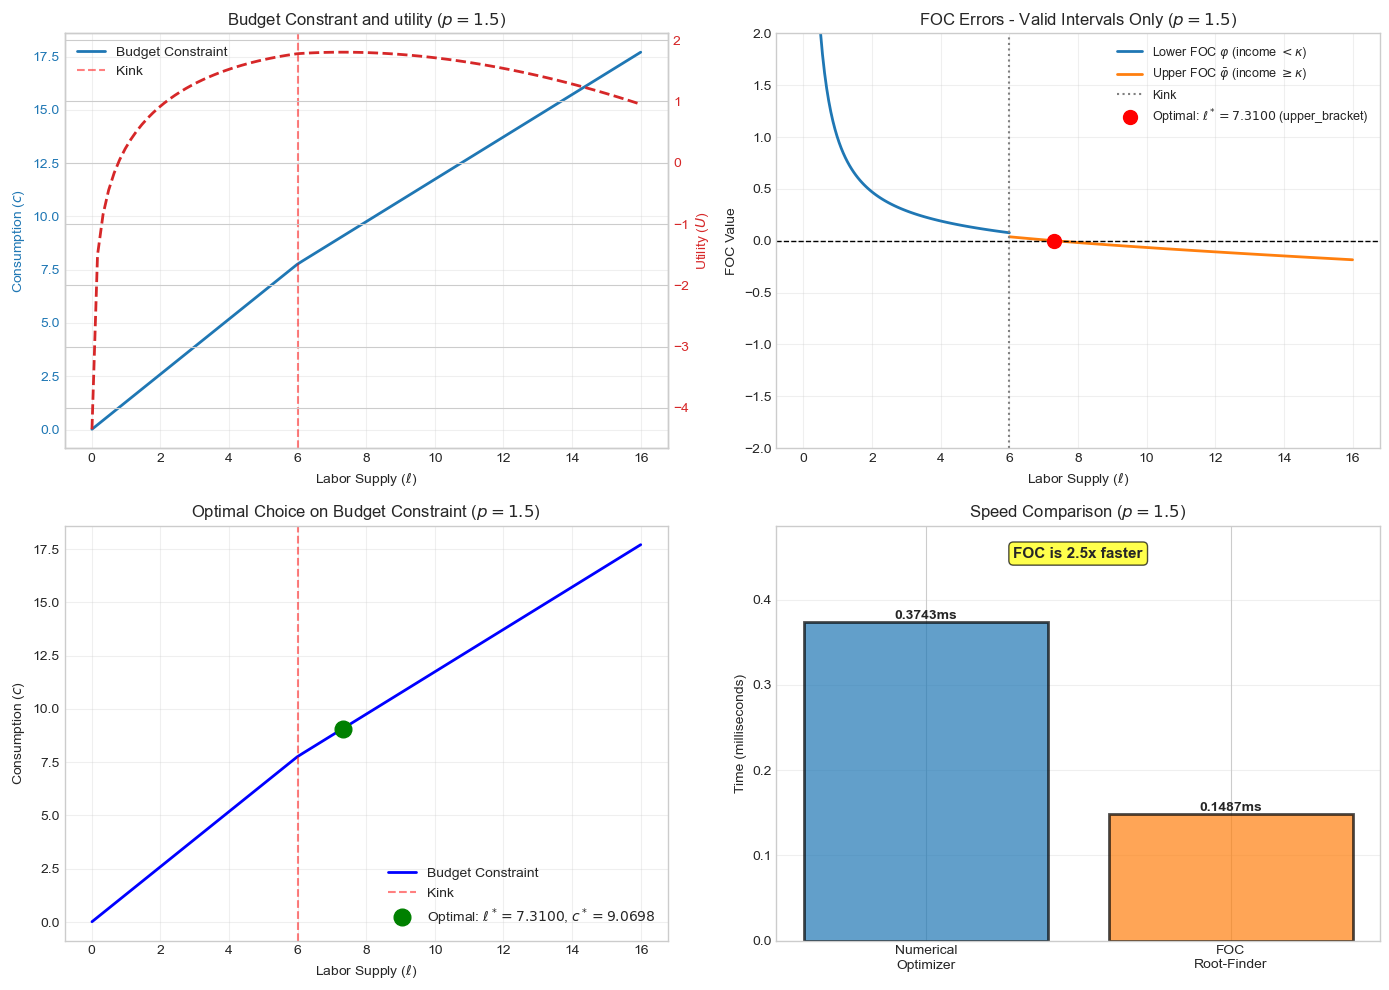


 Summary for p=1.5 ===
Optimal labor supply: 7.3100
Solution: upper_bracket
Consumption: 9.0698
Utility: 1.8042
Speed comparison: Numerical 0.3743ms, FOC 0.1487ms, Speedup 2.5x


In [84]:
from labour_supply_analysis import analyze_labor_supply

# Comprehensive analysis for p = 1.0, 1.175, and 1.5
analyze_labor_supply(1.0, model, par)
analyze_labor_supply(1.175, model, par)
analyze_labor_supply(1.5, model, par)

## 3.1: Labor Supply 

Both methods yields identical optimal labor supply but the FOC rootfinder is significantly faster. We can observe that for the lower bracket regime Plotted for ℓ ∈ [0, κ/wp] Workers are unconstrained by the kink. Workers at the kink (p=1.175) choose to stay exactly at the kink to avoid high top tax. Workers at the top bracket regime has high earnings that outweights the top tax. 


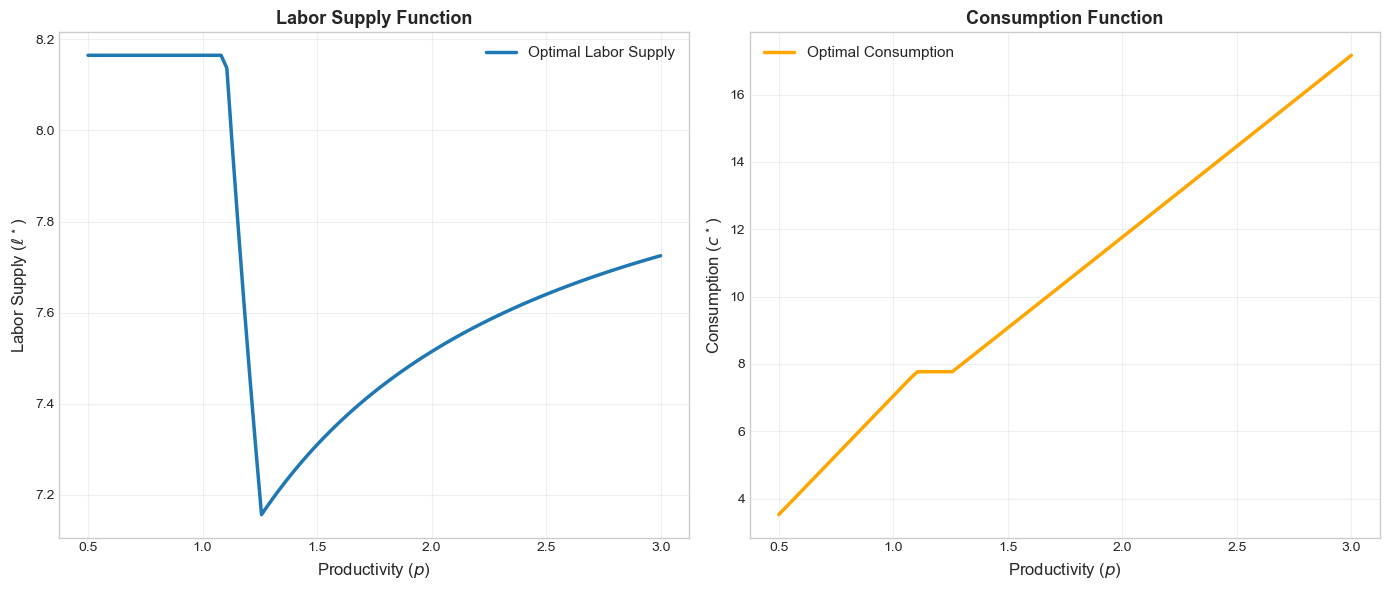

LABOR SUPPLY FUNCTION - BUNCHING ANALYSIS

Total workers analyzed: 100

Workers by solution type:
  Lower bracket (ℓ* < κ/wp): 24 workers (24.0%)
  At kink (ℓ* = κ/wp): 7 workers (7.0%)
  Upper bracket (ℓ* > κ/wp): 69 workers (69.0%)

✓ 7.0% of workers bunch at the kink point

Key insight:
  - Workers with low productivity work in lower bracket
  - Medium productivity workers bunch at kink to avoid top tax
  - Only high productivity workers choose upper bracket


In [85]:
from labour_supply_analysis import analyze_labor_supply_function

# Labor supply function and bunching analysis
labor_results = analyze_labor_supply_function(model, par)

## 3.2: Labor Supply Function
The proportions of workers who works at the different brackets is shown in tabel below.

| Worker Type | Count | Proportion | Labor Supply Range | Interpretation |
|---|---|---|---|---|
| Lower bracket (ℓ*) | 24 | 24% | ℓ* < κ/wp | Work in lower tax regime, unaffected by kink |
| At kink (ℓ*)** | 7 | 7% | ℓ* = κ/wp | Bunching: Optimally constrained by tax discontinuity |
|*Upper bracket (ℓ*) | 69 | 69% | ℓ* > κ/wp | Work in upper tax regime despite higher marginal tax |




(1) WELFARE ANALYSIS WITH TOP TAX
------------------------------------------------------------

Baseline (no top tax, ω=0):
  SWF: 14195.72
  Total Tax Revenue: 11182.47
  Gini: 0.1685

With top tax (ω=0.2, κ=9.0):
  SWF: 14099.56
  Total Tax Revenue: 11460.19
  Gini: 0.1375
  SWF Change: -96.16 (-0.68%)

(2) LORENZ CURVE - INEQUALITY ANALYSIS
------------------------------------------------------------


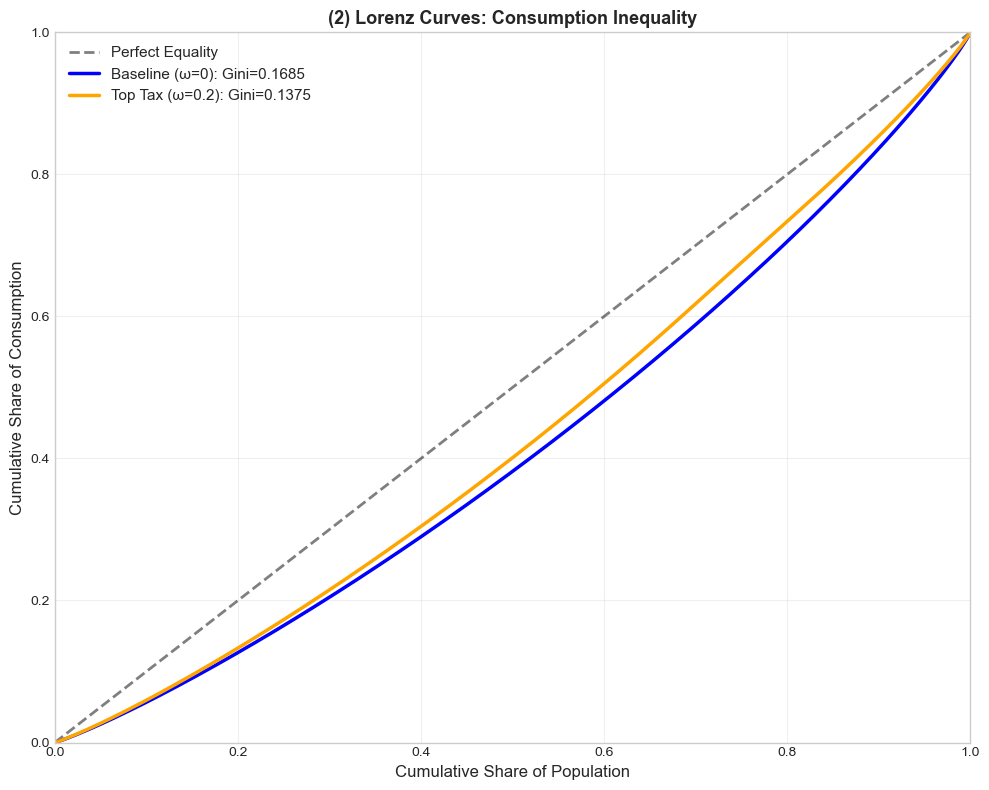


Lorenz Curve Interpretation:
  - Closer to 45° line = more equal distribution
  - Baseline Gini: 0.1685 (less equal)
  - Top Tax Gini: 0.1375 (more equal)
  - Improvement: 18.4% reduction in inequality

(3) Optimal top tax parameters
Searching for better (ω, κ) that maximize SWF...

Best parameters found:
  ω (top tax rate): 0.0000
  κ (cutoff income): 9.0000
  SWF: 14195.7174
  Improvement vs. baseline: 0.0000

⚠ No improvement found
  Current parameters (ω=0.2, κ=9.0) are close to or at the optimum
  Best found: ω=0.0000 yields no improvement



In [86]:
from labour_supply_analysis import analyze_welfare_effects

# Welfare analysis and optimal policy search
welfare_results = analyze_welfare_effects(model, par)

## 3.3: Public Good and Social Welfare Effects

**(1) How does the SWF change when we introduce the top tax?**

The Social Welfare Function decreases by 96.16 points (−0.68%) when the top tax is introduced. SWF is decreases because the combined behavioral distortion and consumption loss (due to the higher tax)outweighs the public good benefit. So for the given parameters the top tax of 20% is **too high** relative to the value citizens place on the public good

**(2) how does consumtion inequality change?**

As you can see on the lorenz curve the top tax reduces consumption inequality. As shown in the output the change is -0,0310 which is about 18.4% reduction in inequality. 

**(3) Search for the optimal ω and κ parameters that maximize SWF**

The optimal top tax to maximize SWF is ω* = 0.0 (no top tax) with κ* = 9.0. That is because the public good valuation (η=0.1) is too low relative to reduction from taxes



## Question 4

We extend the model by introducing heterogeneous preferences. Specifically, we assume that workers differ in their disutility of labor, represented by the parameter $\nu$.

We consider a range of $\nu$ values to see how workers with different preferences respond to changes in the price p. This allows us to analyze how labor supply varies across the population.

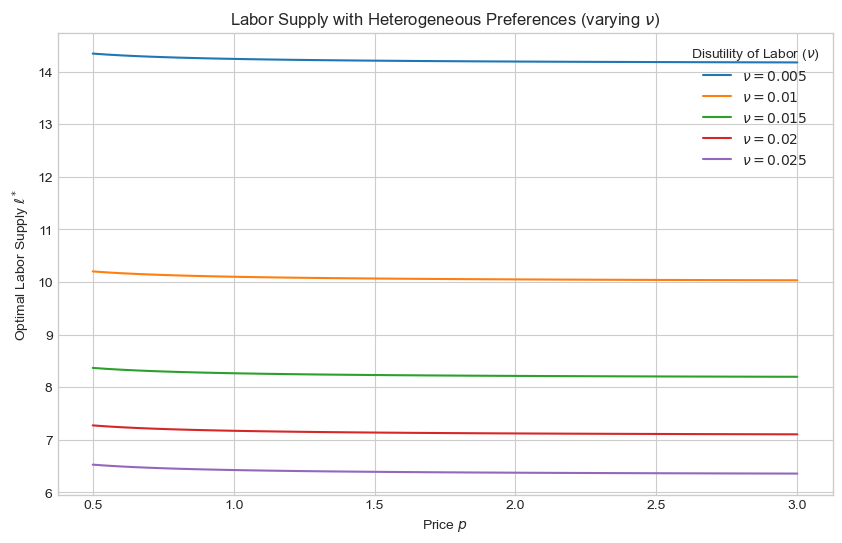

In [87]:
# Define a range of nu values representing different worker types
nu_list = [0.005, 0.01, 0.015, 0.02, 0.025]
p_vec = np.linspace(0.5, 3.0, 50)

plt.figure(figsize=(10,6))

# Loop over each worker type
for nu in nu_list:
    # Create a worker with specific nu
    worker_ext = MyWorkerClass()
    worker_ext.par.nu = nu
    
    ell_vec_ext = np.zeros(len(p_vec))
    
    # Solve for optimal labor supply for this worker type across prices
    for i, p in enumerate(p_vec):
        
        # Define objective
        def obj(ell):
            c = worker_ext.post_tax_income(p, ell)
            return -worker_ext.utility(c, ell)
        
        # Bounds
        ell_min = worker_ext.get_min_ell(p)
        ell_max = worker_ext.par.ell_max
        
        # Optimize
        res = minimize_scalar(obj, bounds=(ell_min, ell_max), method='bounded')
        ell_vec_ext[i] = res.x
        
    # Plot
    plt.plot(p_vec, ell_vec_ext, label=f'$\\nu = {nu}$')

plt.xlabel('Price $p$')
plt.ylabel('Optimal Labor Supply $\ell^*$')
plt.title('Labor Supply with Heterogeneous Preferences (varying $\\nu$)')
plt.legend(title="Disutility of Labor ($\\nu$)")
plt.grid(True)
plt.show()